# Student Performance Prediction using Linear Regression

## Objective

Build a Machine Learning model to predict students' final scores based on academic and lifestyle factors.

## ML Workflow

1. Data Loading
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Data Preprocessing
6. Train / Validation / Test Split
7. Model Training
8. Model Evaluation
9. Model Saving

In [295]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 1. Loading Dataset

In this step, we load the student performance dataset and inspect the initial records.

In [296]:
df = pd.read_csv("dataset/student_scores_1000_linear_regression.csv")

df.head()

,Student_ID,Study_Hours,Attendance,Previous_Score,Assignments_Completed,Sleep_Hours,Internet_Hours,Extra_Classes,Final_Score
0,1,8.0,46.0,70,5.0,5.1,9.1,Yes,64.0
1,2,1.3,50.0,62,5.0,6.5,1.3,Yes,50.7
2,3,8.7,71.0,63,9.0,6.9,9.9,Yes,76.2
3,4,2.8,72.0,78,6.0,4.8,11.5,No,43.4
4,5,5.2,67.0,79,11.0,5.3,1.5,No,70.7


In [297]:
df.shape

(1000, 9)

In [298]:
df.columns

Index(['Student_ID', 'Study_Hours', 'Attendance', 'Previous_Score',
       'Assignments_Completed', 'Sleep_Hours', 'Internet_Hours',
       'Extra_Classes', 'Final_Score'],
      dtype='object')

## 2. Dataset Information

Checking:
- Column data types
- Missing values
- Memory usage

In [299]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             1000 non-null   int64  
 1   Study_Hours            999 non-null    float64
 2   Attendance             999 non-null    float64
 3   Previous_Score         1000 non-null   int64  
 4   Assignments_Completed  999 non-null    float64
 5   Sleep_Hours            999 non-null    float64
 6   Internet_Hours         999 non-null    float64
 7   Extra_Classes          1000 non-null   object 
 8   Final_Score            1000 non-null   float64
dtypes: float64(6), int64(2), object(1)
memory usage: 70.4+ KB


In [300]:
df.describe()

,Student_ID,Study_Hours,Attendance,Previous_Score,Assignments_Completed,Sleep_Hours,Internet_Hours,Final_Score
count,1000.000000,999.000000,999.000000,1000.000000,999.000000,999.000000,999.000000,1000.00000
mean,500.500000,6.535736,72.394394,66.507000,7.059059,6.519419,6.548749,64.20940
std,288.819436,3.225197,15.596895,18.516501,3.162201,1.425668,3.215801,13.24138
min,1.000000,1.000000,45.000000,35.000000,2.000000,4.000000,1.000000,28.80000
25%,250.750000,3.800000,60.000000,50.000000,4.000000,5.300000,3.800000,55.00000
50%,500.500000,6.600000,72.000000,66.500000,7.000000,6.600000,6.600000,63.95000
75%,750.250000,9.200000,86.000000,83.000000,10.000000,7.700000,9.300000,72.92500
max,1000.000000,25.000000,100.000000,98.000000,12.000000,9.000000,12.000000,180.00000


# 3. Data Cleaning

Real-world datasets often contain:
- Missing values
- Duplicate records
- Incorrect data
- Outliers

In this section, we will clean the dataset before model training.

In [301]:
df.isnull().sum()

Student_ID               0
Study_Hours              1
Attendance               1
Previous_Score           0
Assignments_Completed    1
Sleep_Hours              1
Internet_Hours           1
Extra_Classes            0
Final_Score              0
dtype: int64

## 3.1 Handling Missing Values

For numerical features:
- Use median because it is less affected by extreme values.

For categorical features:
- Use mode (most frequent value).

In [302]:
numerical_columns = df.select_dtypes(
    include=["int64","float64"]
).columns

numerical_columns

Index(['Student_ID', 'Study_Hours', 'Attendance', 'Previous_Score',
       'Assignments_Completed', 'Sleep_Hours', 'Internet_Hours',
       'Final_Score'],
      dtype='object')

In [303]:
for col in numerical_columns:
    df[col].fillna(
        df[col].median(),
        inplace=True
    )

In [304]:
df.isnull().sum()

Student_ID               0
Study_Hours              0
Attendance               0
Previous_Score           0
Assignments_Completed    0
Sleep_Hours              0
Internet_Hours           0
Extra_Classes            0
Final_Score              0
dtype: int64

## 3.2 Handling Categorical Missing Values

In [305]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

categorical_columns

Index(['Extra_Classes'], dtype='object')

In [306]:
for col in categorical_columns:
    df[col].fillna(
        df[col].mode()[0],
        inplace=True
    )

In [307]:
df.isnull().sum()

Student_ID               0
Study_Hours              0
Attendance               0
Previous_Score           0
Assignments_Completed    0
Sleep_Hours              0
Internet_Hours           0
Extra_Classes            0
Final_Score              0
dtype: int64

## 3.3 Checking Duplicate Records

Duplicate records can create bias and affect model performance.

In [359]:
df.duplicated().sum()

np.int64(0)

In [309]:
df = df.drop_duplicates()

df.shape

(1000, 9)

# 4. Outlier Detection

Outliers are detected using:
- Boxplots (visual analysis)
- IQR (Interquartile Range) method


In [310]:
numerical_columns = df.select_dtypes(
    include=["int64","float64"]
).columns

numerical_columns

Index(['Student_ID', 'Study_Hours', 'Attendance', 'Previous_Score',
       'Assignments_Completed', 'Sleep_Hours', 'Internet_Hours',
       'Final_Score'],
      dtype='object')

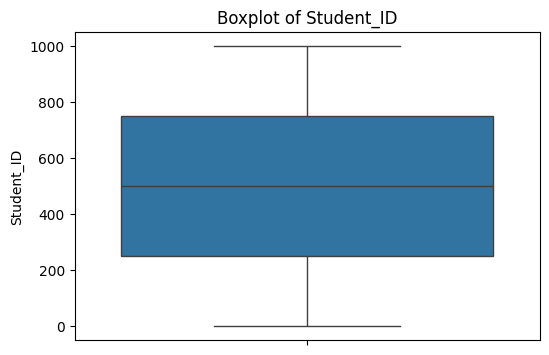

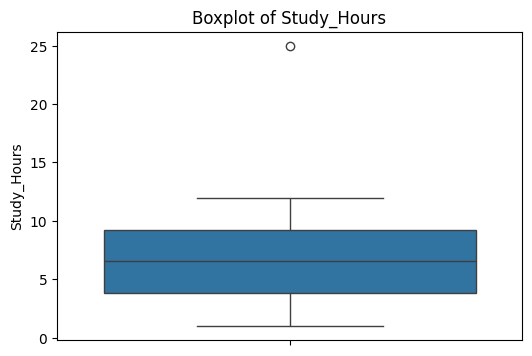

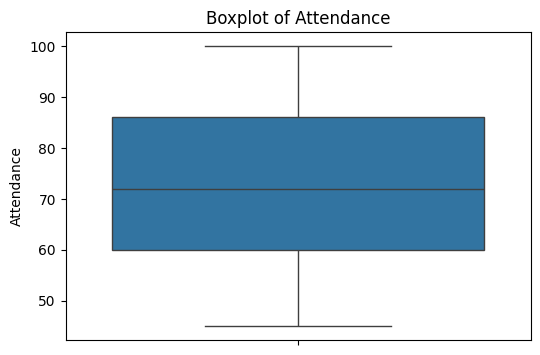

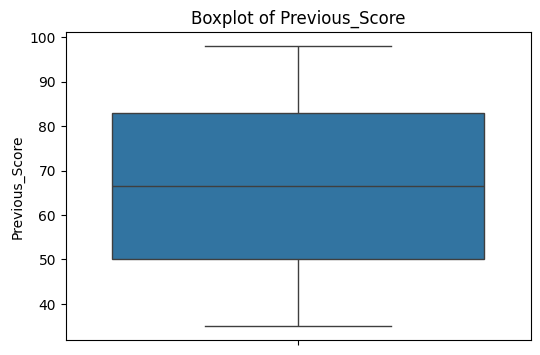

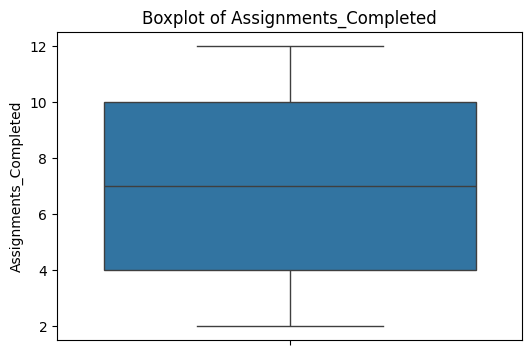

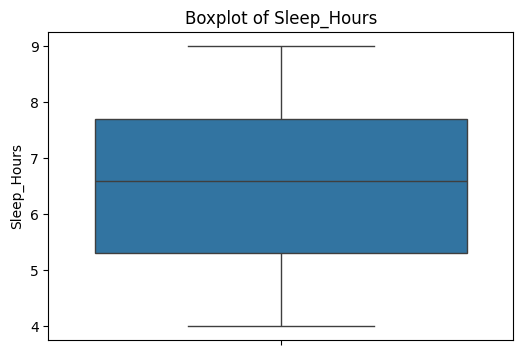

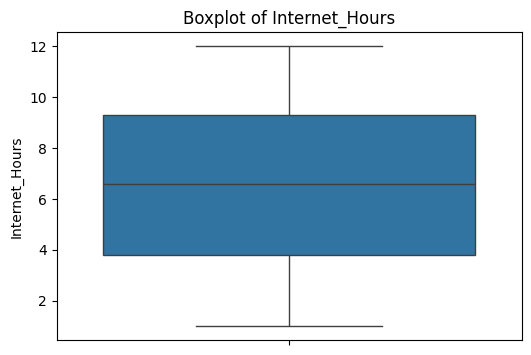

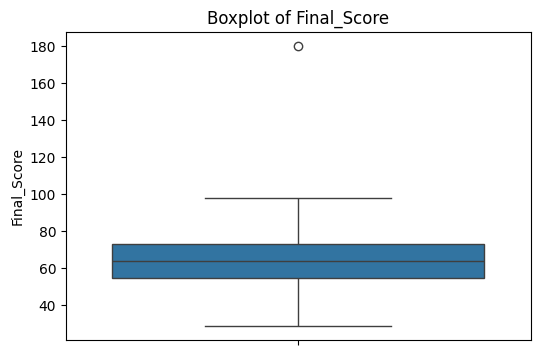

In [311]:
for col in numerical_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        y=df[col]
    )

    plt.title(f"Boxplot of {col}")

    plt.ylabel(col)

    plt.show()

## IQR Method

Formula:

Lower Limit = Q1 - 1.5 × IQR

Upper Limit = Q3 + 1.5 × IQR

Values outside these limits are considered outliers.

In [312]:
def detect_outliers(data, column):

    Q1 = data[column].quantile(0.25)

    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR

    upper_limit = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_limit) |
        (data[column] > upper_limit)
    ]

    return outliers

In [313]:
final_score_outliers = detect_outliers(
    df,
    "Final_Score"
)

final_score_outliers

,Student_ID,Study_Hours,Attendance,Previous_Score,Assignments_Completed,Sleep_Hours,Internet_Hours,Extra_Classes,Final_Score
900,901,11.9,76.0,40,9.0,5.8,8.8,No,180.0


In [314]:
Q1 = df["Final_Score"].quantile(0.25)

Q3 = df["Final_Score"].quantile(0.75)

IQR = Q3 - Q1


df = df[
    (df["Final_Score"] >= Q1 - 1.5*IQR) &
    (df["Final_Score"] <= Q3 + 1.5*IQR)
]


df.shape

(999, 9)

In [315]:
detect_outliers(
    df,
    "Study_Hours"
)

,Student_ID,Study_Hours,Attendance,Previous_Score,Assignments_Completed,Sleep_Hours,Internet_Hours,Extra_Classes,Final_Score
950,951,25.0,79.0,68,5.0,8.2,4.3,No,82.8


In [316]:
Q1 = df["Study_Hours"].quantile(0.25)

Q3 = df["Study_Hours"].quantile(0.75)

IQR = Q3 - Q1


df = df[
    (df["Study_Hours"] >= Q1 - 1.5*IQR) &
    (df["Study_Hours"] <= Q3 + 1.5*IQR)
]


df.shape

(998, 9)

## Data Cleaning Completed 

The dataset is now:
- Missing values handled
- Duplicate records removed
- Outliers treated

Now we can perform Exploratory Data Analysis (EDA).

# 5. Exploratory Data Analysis (EDA)

EDA is performed to analyze patterns, relationships, and trends in the dataset before building the machine learning model.

In [317]:
df.shape

(998, 9)

In [318]:
df.head()

,Student_ID,Study_Hours,Attendance,Previous_Score,Assignments_Completed,Sleep_Hours,Internet_Hours,Extra_Classes,Final_Score
0,1,8.0,46.0,70,5.0,5.1,9.1,Yes,64.0
1,2,1.3,50.0,62,5.0,6.5,1.3,Yes,50.7
2,3,8.7,71.0,63,9.0,6.9,9.9,Yes,76.2
3,4,2.8,72.0,78,6.0,4.8,11.5,No,43.4
4,5,5.2,67.0,79,11.0,5.3,1.5,No,70.7


In [319]:
df.describe()

,Student_ID,Study_Hours,Attendance,Previous_Score,Assignments_Completed,Sleep_Hours,Internet_Hours,Final_Score
count,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000
mean,499.647295,6.511924,72.383768,66.532064,7.059118,6.518537,6.548798,64.074749
std,288.476741,3.168746,15.602896,18.515966,3.162517,1.425209,3.215836,12.722942
min,1.000000,1.000000,45.000000,35.000000,2.000000,4.000000,1.000000,28.800000
25%,250.250000,3.800000,60.000000,50.000000,4.000000,5.300000,3.800000,55.000000
50%,499.500000,6.600000,72.000000,66.500000,7.000000,6.600000,6.600000,63.900000
75%,748.750000,9.175000,86.000000,83.000000,10.000000,7.700000,9.300000,72.900000
max,1000.000000,12.000000,100.000000,98.000000,12.000000,9.000000,12.000000,98.000000


## 5.1 Distribution Analysis

Histograms are used to analyze the distribution of numerical features.

They help identify:
- Data spread
- Frequency of values
- Skewness
- General patterns in the dataset

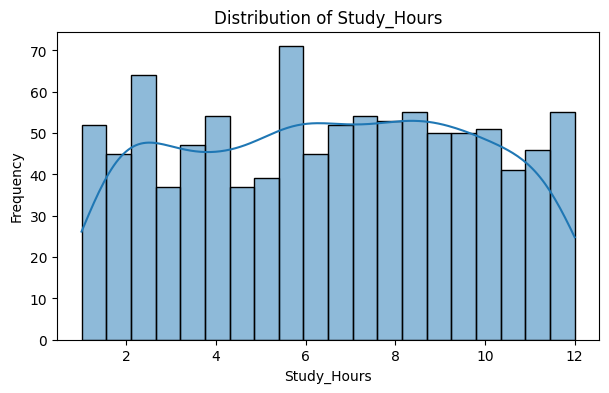

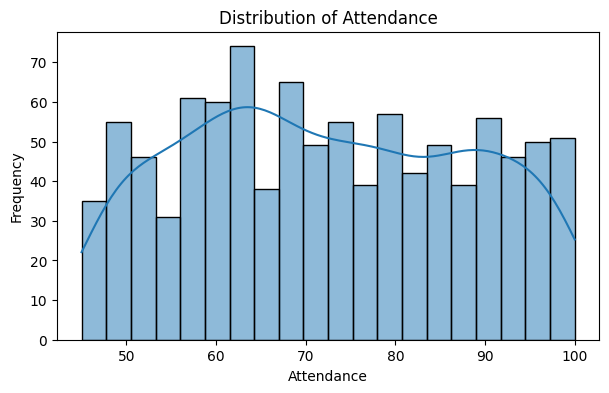

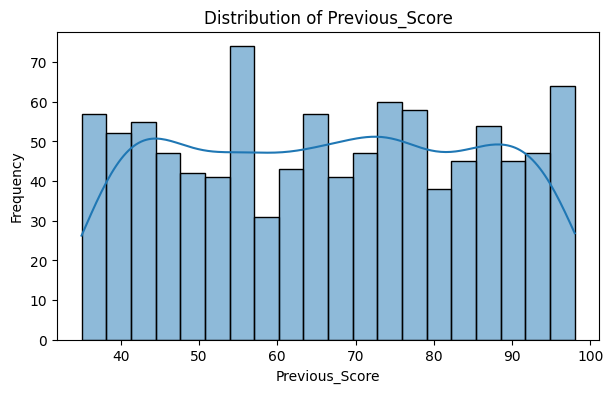

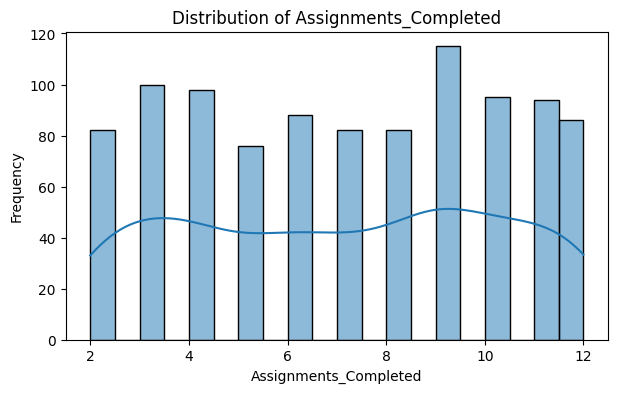

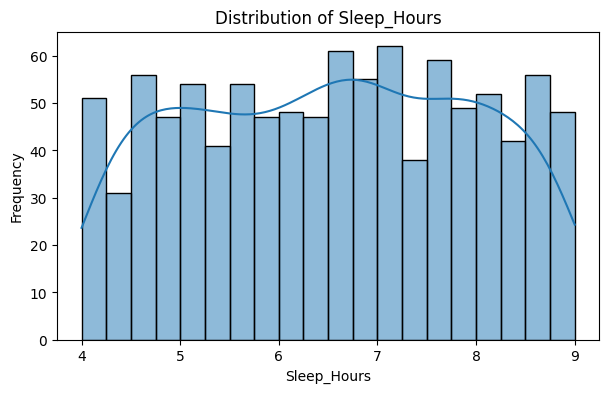

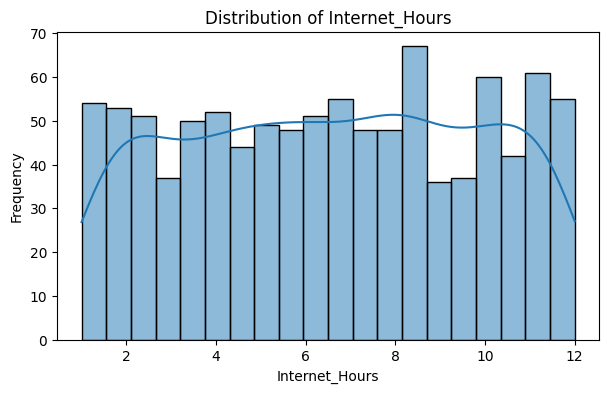

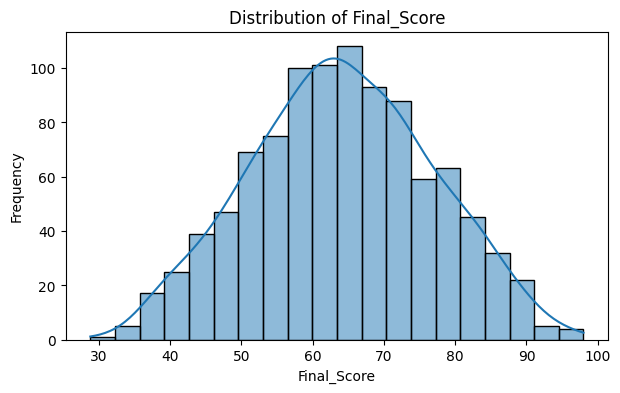

In [320]:
numerical_columns = [
    "Study_Hours",
    "Attendance",
    "Previous_Score",
    "Assignments_Completed",
    "Sleep_Hours",
    "Internet_Hours",
    "Final_Score"
]


for col in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True
    )

    plt.title(f"Distribution of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

## 5.2 Outlier Detection

Box plots are used to identify outliers and understand the spread of numerical variables.

They provide information about:
- Median value
- Data range
- Variability
- Extreme values

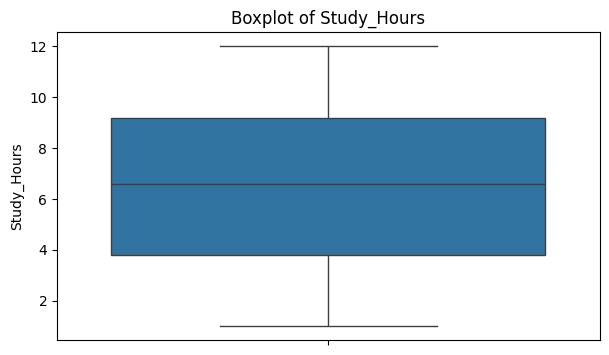

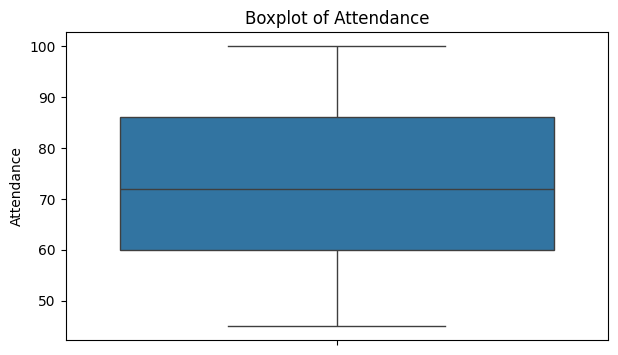

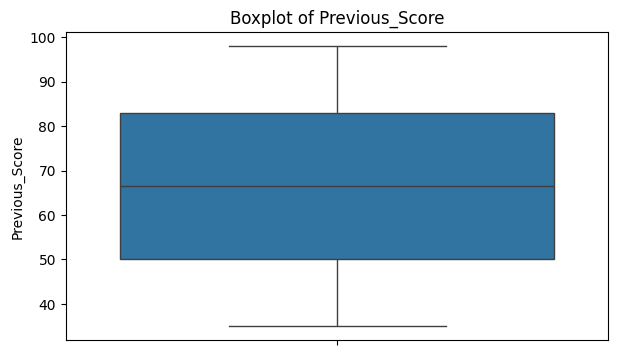

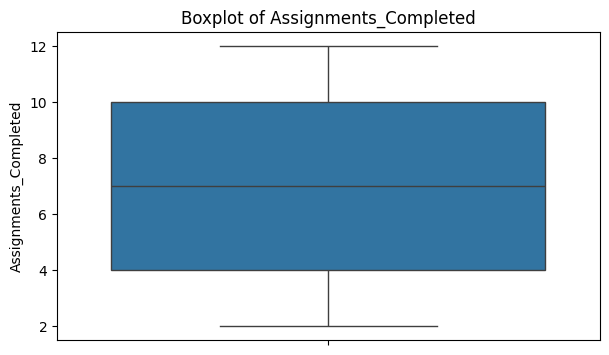

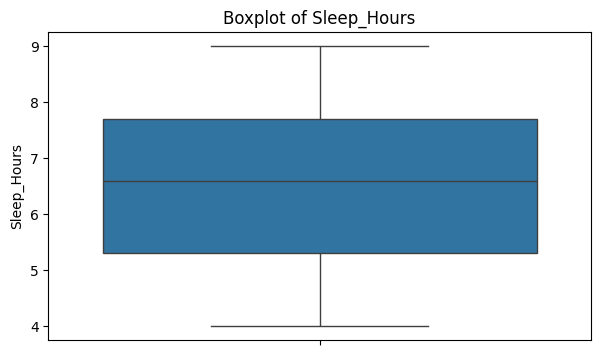

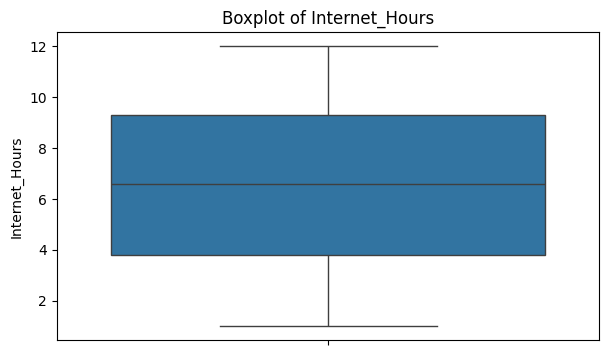

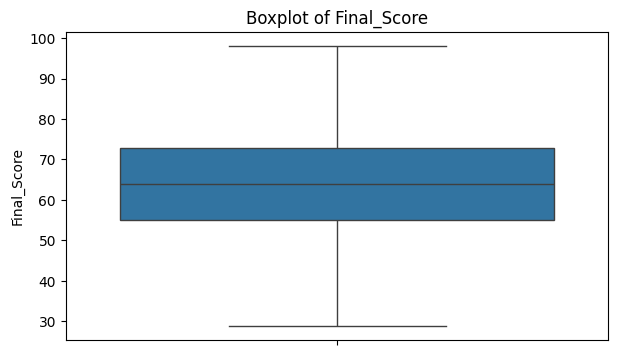

In [321]:
for col in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        y=df[col]
    )

    plt.title(f"Boxplot of {col}")

    plt.ylabel(col)

    plt.show()

## 5.3 Correlation Analysis

Correlation analysis helps identify relationships between numerical variables.

Correlation values range from:

- +1 → Strong positive relationship
- 0 → No relationship
- -1 → Strong negative relationship

This helps identify important features affecting the target variable (Final_Score).

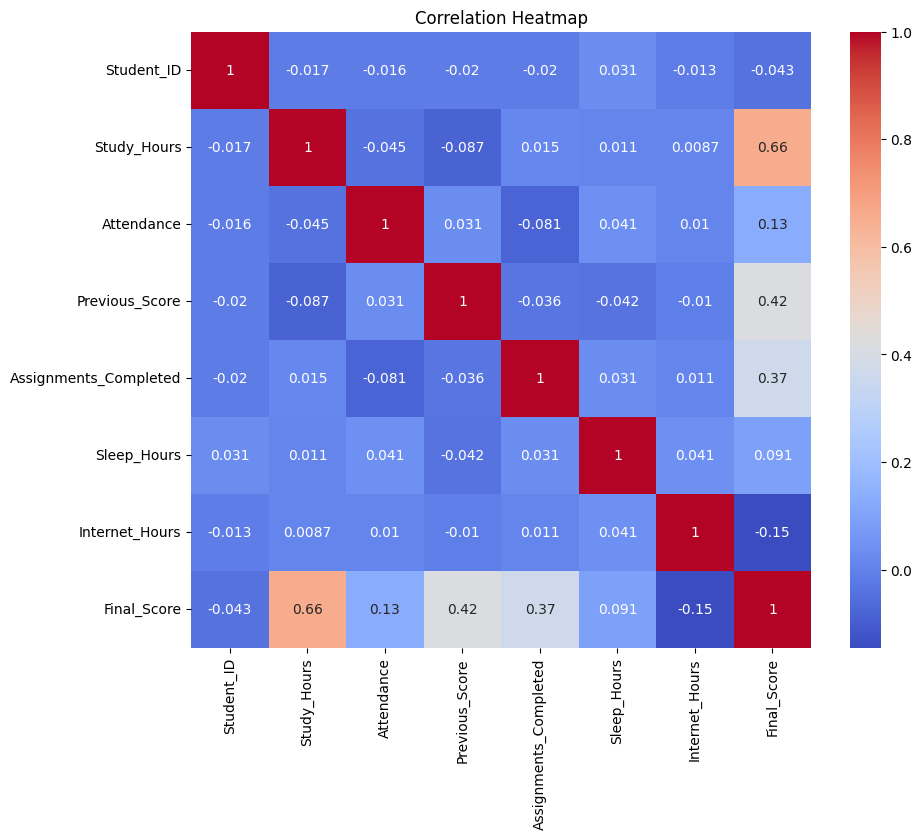

In [322]:
plt.figure(figsize=(10,8))

correlation = df.corr(
    numeric_only=True
)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## 5.4 Feature Relationship Analysis

Scatter plots are used to visualize the relationship between important numerical features and the target variable.

These plots help determine whether a linear relationship exists, which is an important assumption for Linear Regression.

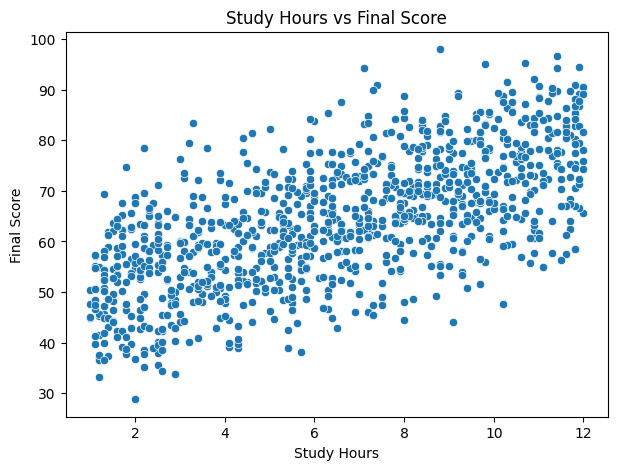

In [323]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Final_Score"
)

plt.title("Study Hours vs Final Score")

plt.xlabel("Study Hours")

plt.ylabel("Final Score")

plt.show()

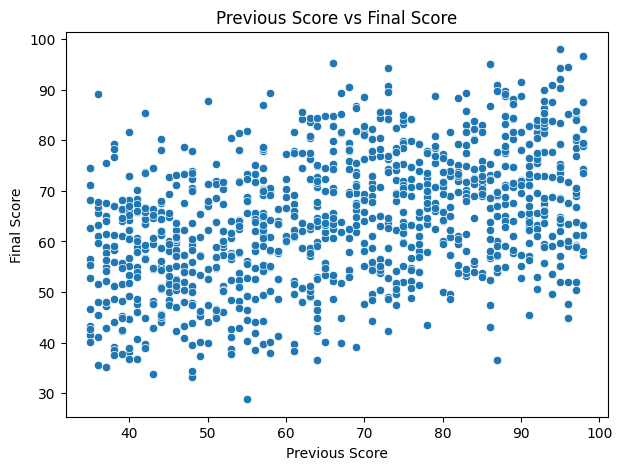

In [324]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Previous_Score",
    y="Final_Score"
)

plt.title("Previous Score vs Final Score")

plt.xlabel("Previous Score")

plt.ylabel("Final Score")

plt.show()

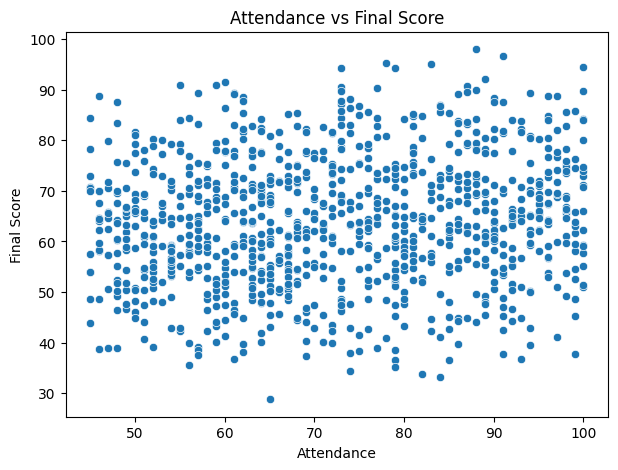

In [325]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Final_Score"
)

plt.title("Attendance vs Final Score")

plt.xlabel("Attendance")

plt.ylabel("Final Score")

plt.show()

## 5.5 Categorical Feature Analysis

Box plots are used to analyze the effect of categorical variables on the target variable.

Here, we analyze whether extra classes influence students' final scores.

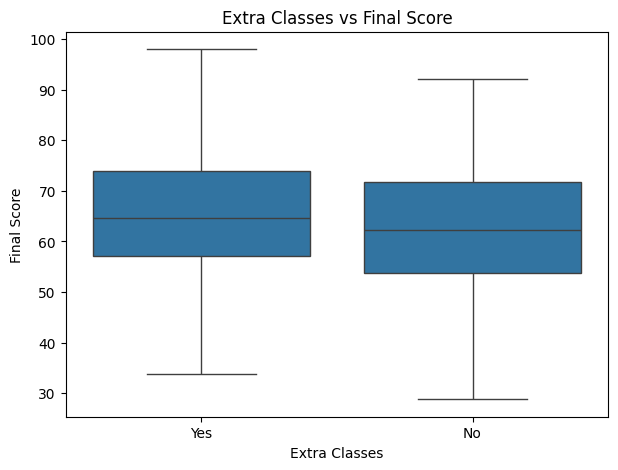

In [326]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Extra_Classes",
    y="Final_Score"
)

plt.title("Extra Classes vs Final Score")

plt.xlabel("Extra Classes")

plt.ylabel("Final Score")

plt.show()

## EDA Summary

From the exploratory analysis:

- Histograms helped understand feature distributions.
- Box plots identified possible outliers in numerical variables.
- Correlation analysis showed relationships between features.
- Scatter plots helped analyze relationships between important features and Final_Score.
- Categorical analysis showed the impact of Extra_Classes on student performance.

The insights obtained from EDA will guide the preprocessing and model development stages.

# 6. Data Preprocessing

Machine learning algorithms work with numerical data.
Therefore, categorical variables must be converted into numerical format before training.

In [327]:
df.dtypes

Student_ID                 int64
Study_Hours              float64
Attendance               float64
Previous_Score             int64
Assignments_Completed    float64
Sleep_Hours              float64
Internet_Hours           float64
Extra_Classes             object
Final_Score              float64
dtype: object

## 6.1 Encoding Categorical Variables

We will convert:
- Yes → 1
- No → 0

using Label Encoding.

In [328]:
df["Extra_Classes"] = df["Extra_Classes"].map(
    {
        "Yes":1,
        "No":0
    }
)

In [329]:
df.head()

,Student_ID,Study_Hours,Attendance,Previous_Score,Assignments_Completed,Sleep_Hours,Internet_Hours,Extra_Classes,Final_Score
0,1,8.0,46.0,70,5.0,5.1,9.1,1,64.0
1,2,1.3,50.0,62,5.0,6.5,1.3,1,50.7
2,3,8.7,71.0,63,9.0,6.9,9.9,1,76.2
3,4,2.8,72.0,78,6.0,4.8,11.5,0,43.4
4,5,5.2,67.0,79,11.0,5.3,1.5,0,70.7


## 6.2 Separating Independent and Dependent Variables

Independent Variables (X):
Features used for prediction.

Dependent Variable (y):
The value we want to predict.

In [330]:
X = df.drop(
    ["Final_Score", "Student_ID"],
    axis=1
)

y = df["Final_Score"]

In [331]:
X.head()

,Study_Hours,Attendance,Previous_Score,Assignments_Completed,Sleep_Hours,Internet_Hours,Extra_Classes
0,8.0,46.0,70,5.0,5.1,9.1,1
1,1.3,50.0,62,5.0,6.5,1.3,1
2,8.7,71.0,63,9.0,6.9,9.9,1
3,2.8,72.0,78,6.0,4.8,11.5,0
4,5.2,67.0,79,11.0,5.3,1.5,0


In [332]:
y.head()

0    64.0
1    50.7
2    76.2
3    43.4
4    70.7
Name: Final_Score, dtype: float64

# Experiment 1: Train-Test Split

Dataset is divided into:
- 80% Training Data
- 20% Testing Data

Training data is used to learn patterns.
Testing data is used for final evaluation.

In [333]:
from sklearn.model_selection import train_test_split

X = df.drop(["Final_Score", "Student_ID"], axis=1)

y = df["Final_Score"]

## Splitting Dataset into Training and Testing Data

The dataset is split using the train_test_split function from Scikit-Learn.

Parameters:
- test_size = 0.2 → 20% data reserved for testing
- random_state = 42 → Ensures reproducibility

In [334]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Dataset Distribution After Train-Test Split

Checking the shape of training and testing datasets ensures that the data has been divided correctly.

In [335]:
print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (798, 7)
Testing Data: (200, 7)


## Training Linear Regression Model

The Linear Regression algorithm is trained using the training dataset.

The model learns the relationship between independent variables (features) and the dependent variable (Final_Score).

In [336]:
model_tt = LinearRegression()

model_tt.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 2.85, 0.15, 0.33,..., 0.81,-0.64, 3.39]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Study_Hours','Attendance','Previous_Score',...,'Sleep_Hours', 'Internet_Hours','Extra_Classes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.8668
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,7


## Prediction on Test Data

After training, the model is used to predict student scores from unseen test data.

In [337]:
y_pred = model_tt.predict(
    X_test
)

## Test Set Evaluation

The model performance is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Lower error values indicate better performance, while a higher R² score indicates that the model explains more variation in the target variable.

In [338]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)


print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3.75754519843592
RMSE: 4.40458962227081
R2 Score: 0.8698505860393426


# Experiment 2: Train-Validation-Test Split

In this experiment, the dataset is divided into three parts:

### Training Data (70%)
Used for learning patterns and fitting the Linear Regression model.

### Validation Data (15%)
Used for evaluating model performance during development and tuning.

### Testing Data (15%)
Used for final evaluation on completely unseen data.

This approach provides a more reliable estimate of model performance.

## First Split: Training and Temporary Dataset

The dataset is first divided into:

- 70% Training Data
- 30% Temporary Data

The temporary data will later be divided into validation and testing datasets.

In [339]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

## Second Split: Validation and Testing Dataset

The remaining 30% data is equally divided into:

- 15% Validation Data
- 15% Testing Data

## Checking Dataset Distribution

Verifying the size of each dataset split.

In [340]:
print("Training Data:", X_train.shape)

print("Validation Data:", X_val.shape)

print("Testing Data:", X_test.shape)

Training Data: (698, 7)
Validation Data: (150, 7)
Testing Data: (200, 7)


## Training Model with Training Dataset

The Linear Regression model is trained only using the training dataset.

The validation dataset is kept separate for unbiased evaluation.

In [341]:
model_tvt = LinearRegression()

model_tvt.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 2.87, 0.15, 0.34,..., 0.75,-0.62, 3.37]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Study_Hours','Attendance','Previous_Score',...,'Sleep_Hours', 'Internet_Hours','Extra_Classes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.183
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,7


## Validation Set Evaluation

The validation dataset is used to evaluate model performance during development.

Evaluation metrics:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [343]:
val_prediction = model_tvt.predict(
    X_val
)


val_mae = mean_absolute_error(
    y_val,
    val_prediction
)

val_mse = mean_squared_error(
    y_val,
    val_prediction
)

val_rmse = np.sqrt(val_mse)

val_r2 = r2_score(
    y_val,
    val_prediction
)


print("Validation MAE :", val_mae)
print("Validation MSE :", val_mse)
print("Validation RMSE:", val_rmse)
print("Validation R2 Score:", val_r2)

Validation MAE : 3.889779039858949
Validation MSE : 21.369636160228403
Validation RMSE: 4.622730379356815
Validation R2 Score: 0.8525232722805615


## Final Testing Evaluation

The testing dataset contains unseen data.

These metrics represent the final performance of the trained Linear Regression model.

In [344]:
test_prediction = model_tvt.predict(
    X_test
)


test_mae = mean_absolute_error(
    y_test,
    test_prediction
)

test_mse = mean_squared_error(
    y_test,
    test_prediction
)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(
    y_test,
    test_prediction
)


print("Test MAE :", test_mae)
print("Test MSE :", test_mse)
print("Test RMSE:", test_rmse)
print("Test R2 Score:", test_r2)

Test MAE : 3.7596946726844602
Test MSE : 19.413718522820574
Test RMSE: 4.406100148977616
Test R2 Score: 0.869761302862974


In [345]:
train_prediction = model_tvt.predict(X_train)

# 7. Model Performance Comparison

We compare the performance of the Linear Regression model on:

- Training Dataset
- Validation Dataset
- Testing Dataset

A similar performance across all datasets indicates that the model generalizes well to unseen data.

In [346]:
train_prediction = model_tvt.predict(
    X_train
)

In [347]:
def evaluate_model(actual, predicted, dataset_name):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    mse = mean_squared_error(
        actual,
        predicted
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        actual,
        predicted
    )

    print(dataset_name)
    print("----------------------")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print()

In [348]:
evaluate_model(
    y_train,
    train_prediction,
    "Training Data"
)


evaluate_model(
    y_val,
    val_prediction,
    "Validation Data"
)


evaluate_model(
    y_test,
    test_prediction,
    "Testing Data"
)

Training Data
----------------------
MAE : 3.794595253104431
MSE : 19.63866304670868
RMSE: 4.4315531190214426
R2 Score: 0.878346774723599

Validation Data
----------------------
MAE : 3.889779039858949
MSE : 21.369636160228403
RMSE: 4.622730379356815
R2 Score: 0.8525232722805615

Testing Data
----------------------
MAE : 3.7596946726844602
MSE : 19.413718522820574
RMSE: 4.406100148977616
R2 Score: 0.869761302862974



## Observation

The training, validation, and testing scores are similar.

This indicates that the Linear Regression model is not overfitting and is able to generalize well on unseen student data.

# 8. Model Visualization

Visualizing model predictions helps analyze:

- How close predictions are to actual values
- Prediction errors
- Model performance patterns

## 8.1 Actual vs Predicted Values

This plot compares the actual student scores with the scores predicted by the Linear Regression model.

A good model will have points close to the diagonal line.

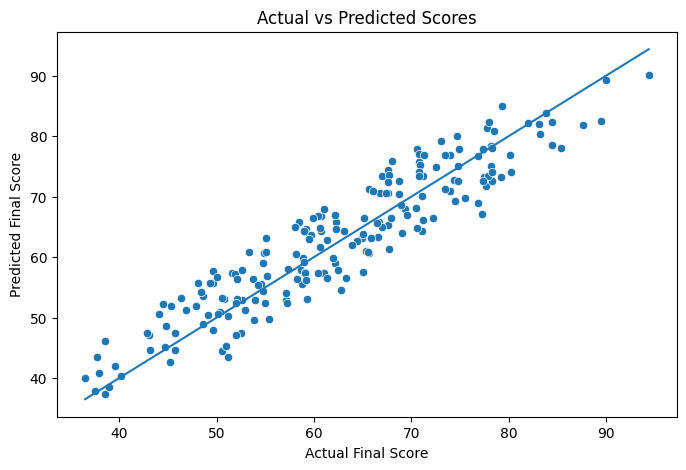

In [349]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_test,
    y=test_prediction
)

plt.xlabel("Actual Final Score")

plt.ylabel("Predicted Final Score")

plt.title("Actual vs Predicted Scores")


# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

## 8.2 Residual Analysis

Residual is the difference between:

Actual Value - Predicted Value

Residual = y - ŷ

A good regression model should have residuals randomly distributed around zero.

In [350]:
residuals = y_test - test_prediction

residuals.head()

453    1.800953
792   -4.846793
209    3.112089
309   -0.771360
739    1.046248
Name: Final_Score, dtype: float64

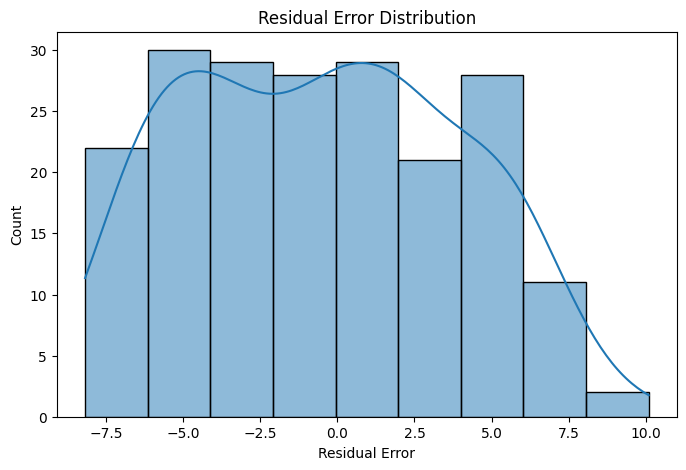

In [351]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Error Distribution")

plt.xlabel("Residual Error")

plt.show()

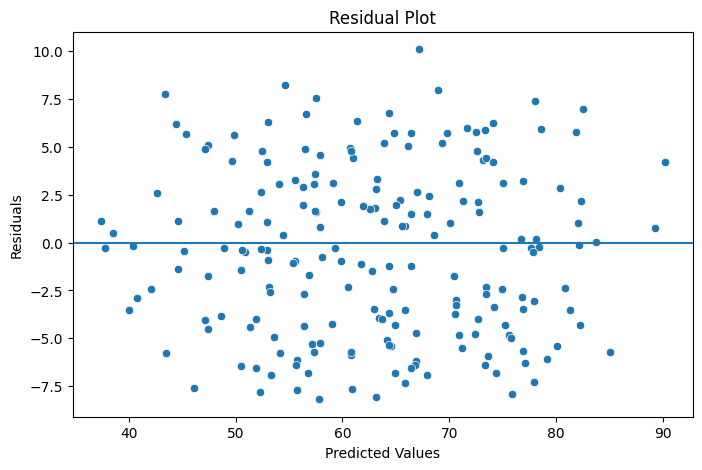

In [352]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=test_prediction,
    y=residuals
)

plt.axhline(
    y=0
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

## Observation

- Residuals are distributed around zero.
- No strong pattern is observed.
- The model is able to capture the relationship between features and Final_Score.

# 9. Saving the Trained Model

After successful training and evaluation, the trained Linear Regression model is saved using the pickle library.

Saving the model allows us to reuse it without retraining every time.

In [353]:
import pickle

In [354]:
with open("linear_regression_student_score_model.pkl", "wb") as file:
    pickle.dump(model_tvt, file)

# 10. Loading Saved Model

The saved model can be loaded and used for prediction without training again.

In [355]:
with open(
    "linear_regression_student_score_model.pkl",
    "rb"
) as file:

    loaded_model = pickle.load(file)

In [356]:
loaded_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 2.87, 0.15, 0.34,..., 0.75,-0.62, 3.37]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Study_Hours','Attendance','Previous_Score',...,'Sleep_Hours', 'Internet_Hours','Extra_Classes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.183
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,7


# 11. Prediction on New Student Data

The trained model can predict the final score of a new student based on input features.

In [357]:
new_student = pd.DataFrame({

    "Study_Hours":[7.5],

    "Attendance":[90],

    "Previous_Score":[85],

    "Assignments_Completed":[9],

    "Sleep_Hours":[7],

    "Internet_Hours":[3],

    "Extra_Classes":[1]

})

In [358]:
prediction = loaded_model.predict(
    new_student
)

prediction

array([82.9669112])

# Conclusion

The Linear Regression model was developed to predict student performance using academic and behavioral features.

The model was evaluated using MAE, RMSE, and R² Score on validation and test datasets to analyze its performance and generalization capability on unseen data.

The complete workflow included:

- Data cleaning
- Exploratory Data Analysis
- Feature preprocessing
- Train-Test evaluation
- Train-Validation-Test evaluation
- Model evaluation
- Model saving
- Prediction pipeline development

The saved model can be reused for future predictions on new student data.